# Objectives

   - Understand the distribution of every feature.
   - Discover relationships between variables.
   - Identify trends affecting car prices.
   - Generate professional visualizations.
   - Save figures for the technical report and presentation.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

pd.set_option("display.max_columns", None)

# Plot Style
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [2]:
df = pd.read_csv("../data/processed/used_cars_clean.csv")

print(df.shape)

df.head()

(3642, 16)


,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price,car_age,milage_per_year,luxury_brand,vehicle_age
0,Ford,Utility Police Interceptor Base,2013,51000,E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,10300,13,3642.857143,0,Old
1,Hyundai,Palisade SEL,2021,34742,Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,38005,5,5790.333333,0,Medium
2,Lexus,RX 350 RX 350,2022,22372,Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,Yes,54598,4,4474.400000,1,Medium
3,INFINITI,Q50 Hybrid Sport,2015,88900,Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,15500,11,7408.333333,0,Old
4,Audi,Q3 45 S line Premium Plus,2021,9835,Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,Yes,34999,5,1639.166667,1,Medium


In [20]:
# Summary Statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
model_year,3642.0,2015.741076,5.495968,2000.0,2012.00000,2017.00000,2020.000000,2024.0
milage,3642.0,64420.059308,46693.330590,100.0,25990.25000,55000.00000,94000.000000,202055.0
price,3642.0,34209.832784,21233.059917,2000.0,17500.00000,30000.00000,46000.000000,99000.0
car_age,3642.0,10.258924,5.495968,2.0,6.00000,9.00000,14.000000,26.0
milage_per_year,3642.0,5528.357448,3217.781449,20.0,3093.72619,5186.34375,7492.670455,24639.0
luxury_brand,3642.0,0.384679,0.486586,0.0,0.00000,0.00000,1.000000,1.0


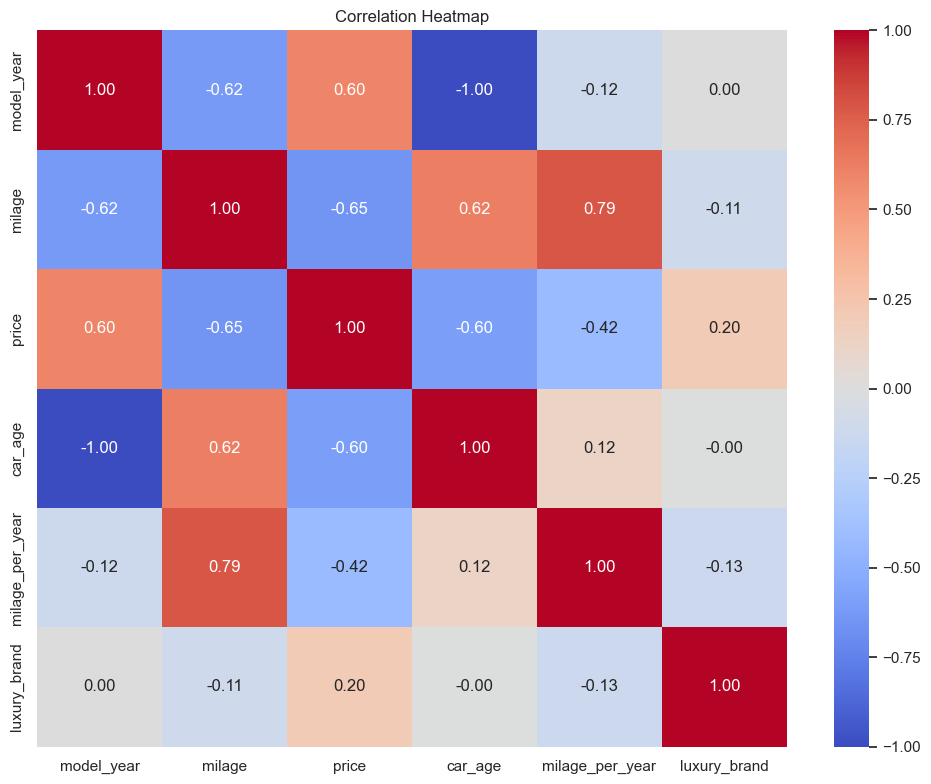

In [4]:
# Correlation Matrix (Numerical Features)
corr = df.select_dtypes(include=np.number).corr()
plt.figure(figsize=(10,8))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("../outputs/figures/correlation_heatmap.png", dpi=300)
plt.show()

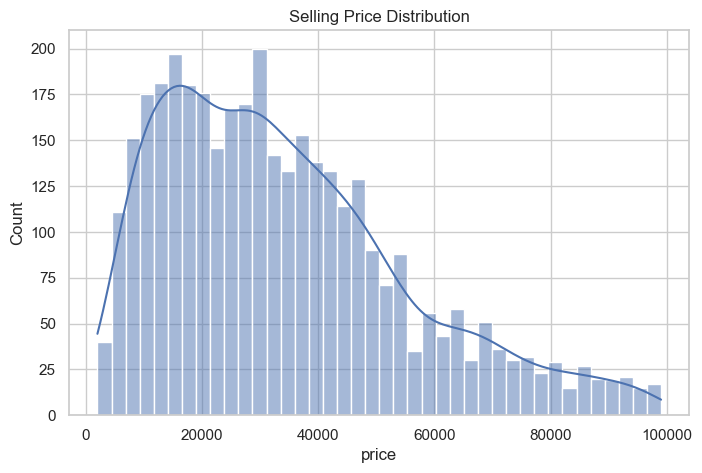

In [5]:
plt.figure(figsize=(8,5))
sns.histplot(
    df["price"],
    bins=40,
    kde=True)
plt.title("Selling Price Distribution")
plt.savefig("../outputs/figures/price_distribution.png", dpi=300)
plt.show()

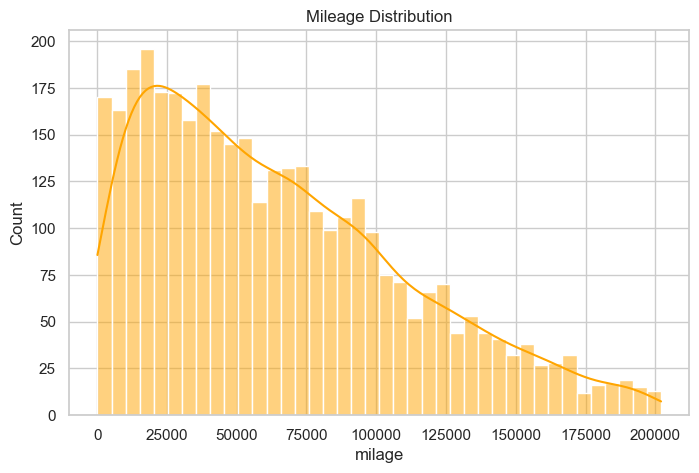

In [6]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["milage"],
    bins=40,
    kde=True,
    color="orange"
)

plt.title("Mileage Distribution")
plt.savefig("../outputs/figures/mileage_distribution.png", dpi=300)
plt.show()

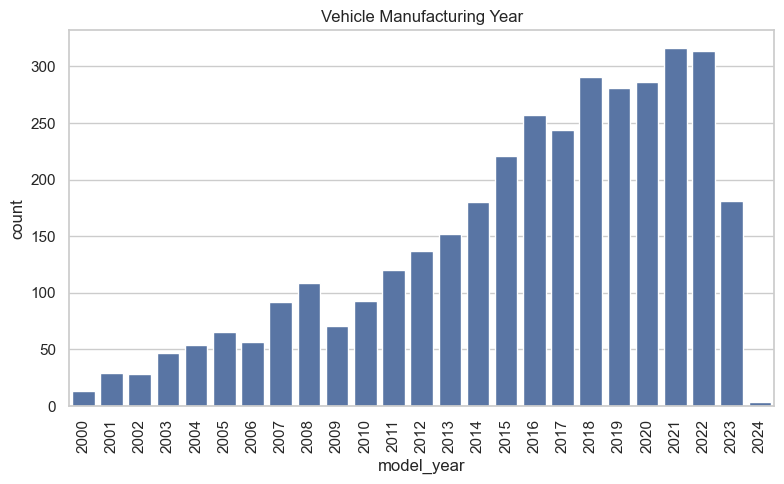

In [7]:
plt.figure(figsize=(8,5))
sns.countplot(
    x="model_year",
    data=df)
plt.xticks(rotation=90)
plt.title("Vehicle Manufacturing Year")
plt.tight_layout()
plt.savefig("../outputs/figures/model_year_distribution.png", dpi=300)
plt.show()

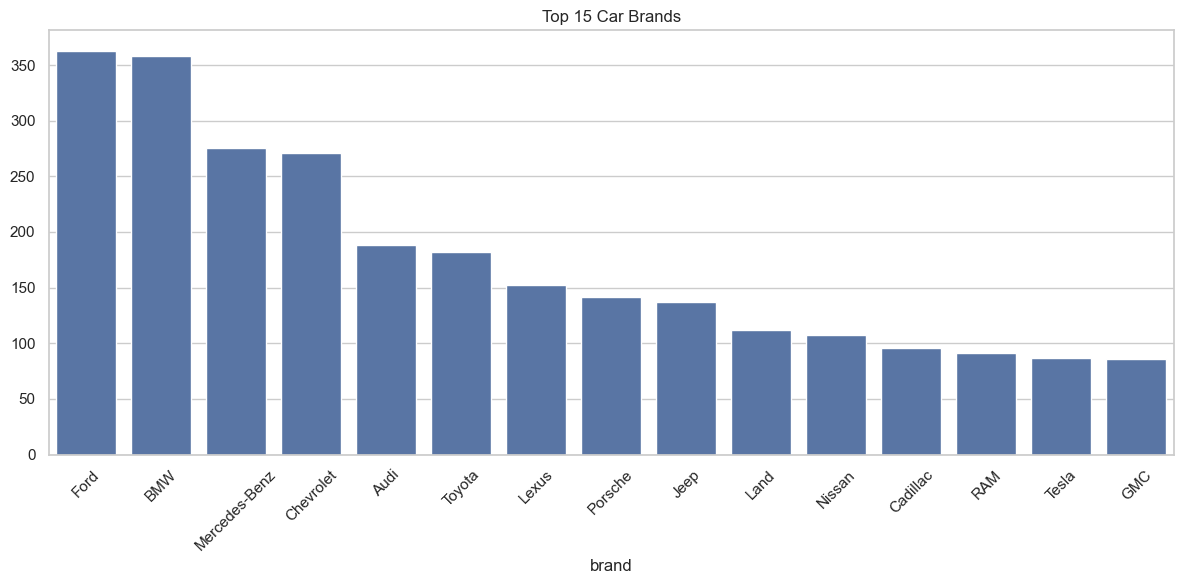

In [8]:
top_brands = df["brand"].value_counts().head(15)
plt.figure(figsize=(12,6))
sns.barplot(
    x=top_brands.index,
    y=top_brands.values
)
plt.xticks(rotation=45)
plt.title("Top 15 Car Brands")
plt.tight_layout()
plt.savefig("../outputs/figures/top_brands.png", dpi=300)
plt.show()

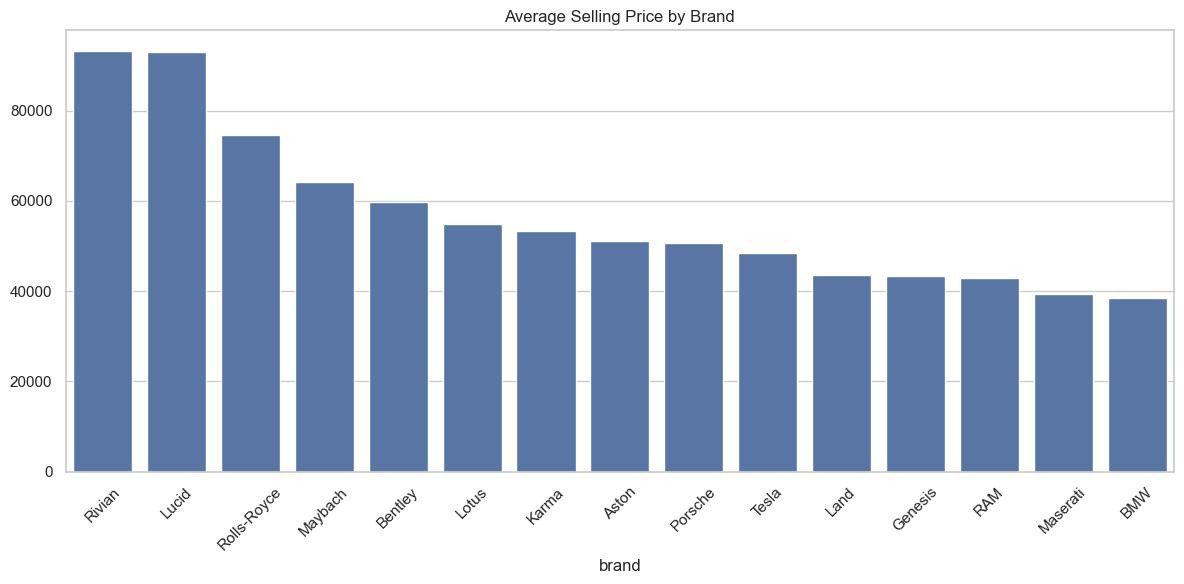

In [9]:
brand_price = (
    df.groupby("brand")["price"]
      .mean()
      .sort_values(ascending=False)
      .head(15)
)

plt.figure(figsize=(12,6))
sns.barplot(
    x=brand_price.index,
    y=brand_price.values
)

plt.xticks(rotation=45)

plt.title("Average Selling Price by Brand")

plt.tight_layout()

plt.savefig("../outputs/figures/average_price_brand.png", dpi=300)

plt.show()

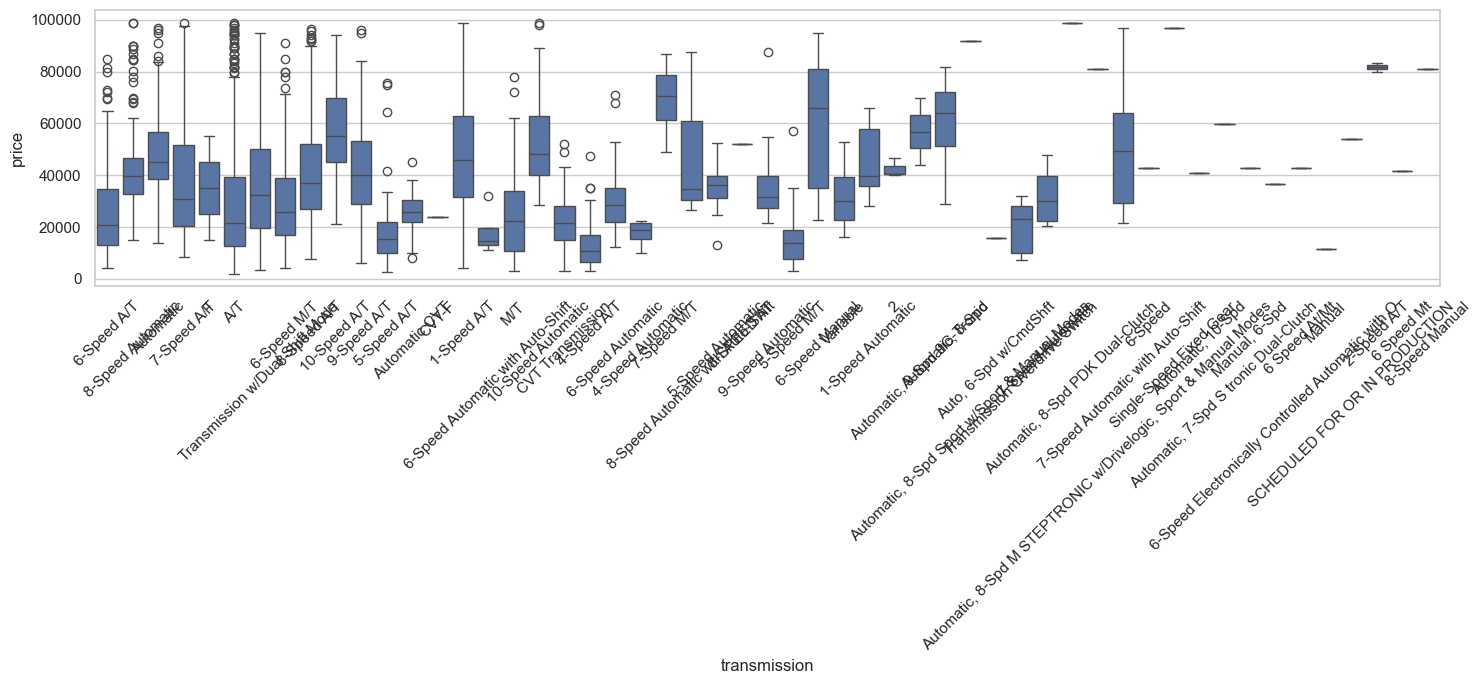

In [11]:
plt.figure(figsize=(15,7))

sns.boxplot(
    x="transmission",
    y="price",
    data=df
)

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("../outputs/figures/transmission_price.png", dpi=300)

plt.show()

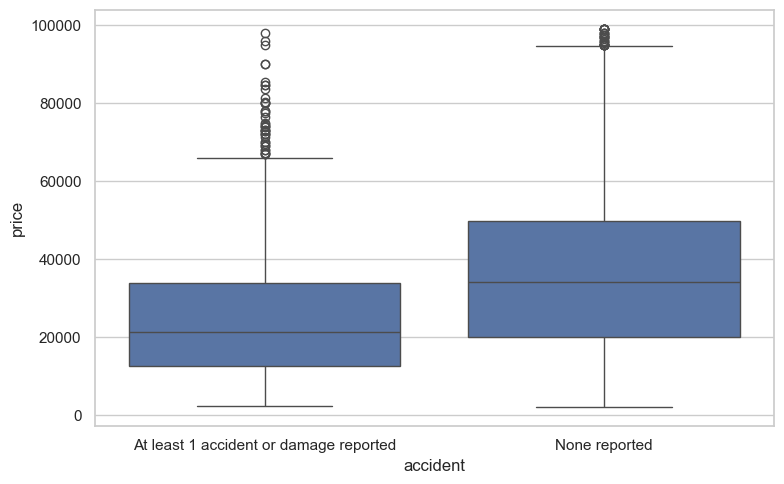

In [12]:
plt.figure(figsize=(8,5))
sns.boxplot(
    x="accident",
    y="price",
    data=df)
plt.tight_layout()
plt.savefig("../outputs/figures/accident_price.png", dpi=300)
plt.show()

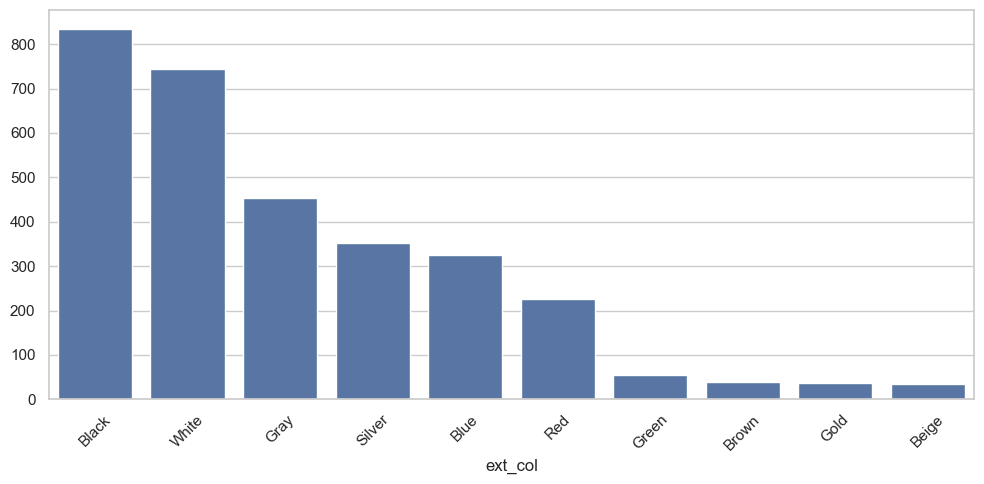

In [13]:
top_colors = df["ext_col"].value_counts().head(10)
plt.figure(figsize=(10,5))
sns.barplot(
    x=top_colors.index,
    y=top_colors.values
)

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../outputs/figures/exterior_colors.png", dpi=300)
plt.show()

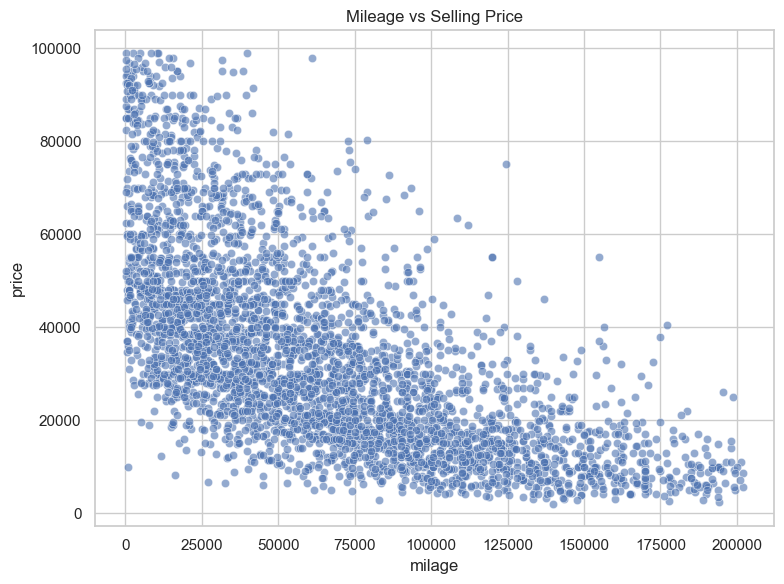

In [14]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x="milage",
    y="price",
    data=df,
    alpha=0.)
plt.title("Mileage vs Selling Price")
plt.tight_layout()
plt.savefig("../outputs/figures/mileage_vs_price.png", dpi=300)
plt.show()

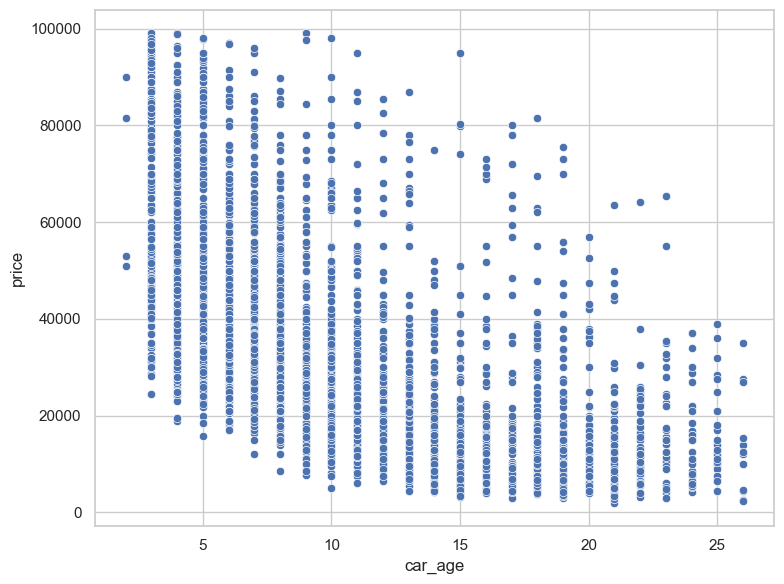

In [15]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x="car_age",
    y="price",
    data=df)
plt.tight_layout()
plt.savefig("../outputs/figures/car_age_price.png", dpi=300)
plt.show()

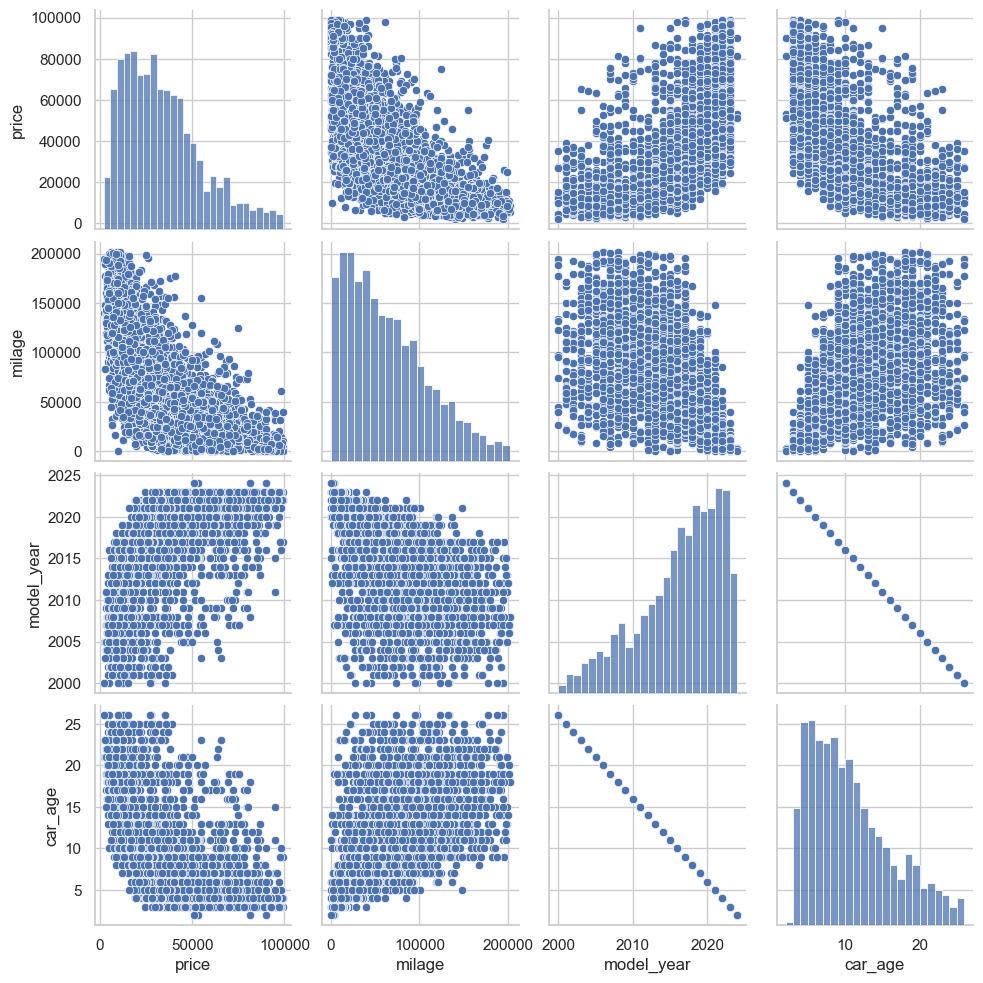

In [16]:
sns.pairplot(
    df[
        [
            "price",
            "milage",
            "model_year",
            "car_age"
        ]
    ]
)

plt.savefig("../outputs/figures/pairplot.png", dpi=300)

plt.show()

In [17]:
fig = px.scatter(
    df,
    x="milage",
    y="price",
    color="brand",
    hover_data=["model"])
fig.show()

## Key Insights

- Luxury brands generally have higher average selling prices.
- Newer vehicles tend to sell for more than older vehicles.
- Vehicles with lower mileage generally have higher prices.
- Accident history negatively affects resale value.
- Brand is one of the strongest predictors of price.
- Model year has a positive relationship with price.
- Mileage has a negative relationship with price.
- Most cars in the dataset are manufactured after 2015.
- The price distribution is right-skewed due to premium vehicles.

In [21]:
summary = df.describe(include="all")
summary.to_csv("../outputs/tables/summary_statistics.csv")

In [22]:
corr.to_csv("../outputs/tables/correlation_matrix.csv")